# TDCOSMO sample
This notebook compiles the TDCOSMO sample. It uses the 1d Ddt posteriors from the power-law models and re-processes the kinematics to allow for an explicit treatment of the kinematic assumptions in a hierarchical way.

The first part is to re-compute the kinematics to derive a covariance matrix to be used in the hierarchical analysis. The second part performs the hierarchical sampling of the mass profile and cosmological parameters for the TDCOSMO sample.

Requirements:
- lenstronomy (https://github.com/lenstronomy/lenstronomy)
- hierarc (https://github.com/sibirrer/hierArc)

Author: TDCOSMO collaboration



In [1]:
from hierarc.LensPosterior.ddt_kin_constraints import DdtKinConstraints
from hierarc.Sampling.mcmc_sampling import MCMCSampler
from lenstronomy.Analysis.light_profile import LightProfileAnalysis
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.Util import param_util
import lenstronomy.Util.multi_gauss_expansion as mge
import corner
import emcee
import numpy as np
import pickle
import copy
import os
import csv
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

import sklearn
from pylab import rc
rc('axes', linewidth=2)
rc('xtick',labelsize=15)
rc('ytick',labelsize=15)

#%load_ext autoreload
#%autoreload 2


In [2]:
# names of the TDCOSMO lenses
TDCOSMO_lenses = ['B1608+656', 'RXJ1131-1231', 'HE0435-1223', 'SDSS1206+4332', 
                  'WFI2033-4723', 'PG1115+080', 'DES0408-5354', 'WGD2038-4008']

# set relative paths to working directory and data
dir_path = os.getcwd()
path2processed = dir_path

# file containing the meta-data of all the lenses (i.e. redshifts and marginal lens model parameter posteriors)

yaml_name = 'tdcosmo_sample.yaml'

yaml_file_path = os.path.join(dir_path, yaml_name)
path2posteriors = os.path.join(dir_path, 'TDCOSMO_data')

In [3]:
# numerical settings (not needed if power-law profiles with Hernquist light distribution is computed)
kwargs_numerics_galkin = {'interpol_grid_num': 1000,  # numerical interpolation, should converge -> infinity
                          'log_integration': True,  # log or linear interpolation of surface brightness and mass models
                           'max_integrate': 100, 'min_integrate': 0.001}  # lower/upper bound of numerical integrals

anisotropy_model = 'const'  # 'OM', 'GOM' or 'const'

# the kinematics has already been pre-processed and saved. If you want to redo it for a (partial) sample, you can add those to the list
recompute_lenses = [] # 'RXJ1131-1231', 'HE0435-1223', 'SDSS1206+4332', 'WFI2033-4723', 'DES0408-5354', 'B1608+656', 'PG1115+080', 'WGD2038-4008'

# number of draws from the lens model posterior to compute the kinematics
num_sample_model = 200  # number of kinematics to be computed from the lensing posterior to compute the covariance matrix for a single slit observation (single Gaussian) 
num_sample_model_multi_obs = 500  # to calculate the covariance matrix between multiple observations, more samples are needed than for a single data point

In [4]:

def light_model_arguments(table, mge=True, light_model_type=None):
    """
    reads out the light model configuration
    :return: lens_light_model_list, kwargs_lens_light
    """
    if light_model_type is None:
        row = table
    else:
        row = table[light_model_type]
    light_model = str(row['light_model'])
    if light_model in ['single_sersic', 'double_sersic', 'triple_sersic']  or (light_model == 'mge' and not mge):
        r_sersic_1, n_sersic_1, amp_sersic_1 = float(row['r_sersic_1']), float(row['n_sersic_1']), float(row['amp_sersic_1'])
        e1_1_light, e2_1_light = float(row['e1_sersic1']), float(row['e2_sersic1'])
        kwargs_lens_light = [{'R_sersic': r_sersic_1, 'amp': amp_sersic_1, 'n_sersic': n_sersic_1, 'e1': e1_1_light, 'e2': e2_1_light, 'center_x': 0, 'center_y': 0}]
        lens_light_model_list=['SERSIC_ELLIPSE']
        if light_model in ['double_sersic', 'triple_sersic']  or (light_model == 'mge' and not mge):
            r_sersic_2, n_sersic_2, amp_sersic_2 = float(row['r_sersic_2']), float(row['n_sersic_2']), float(row['amp_sersic_2'])
            e1_2_light, e2_2_light = float(row['e1_sersic2']), float(row['e2_sersic2'])
            kwargs_lens_light.append({'R_sersic': r_sersic_2, 'amp': amp_sersic_2, 'n_sersic': n_sersic_2, 'e1': e1_2_light, 'e2': e2_2_light, 'center_x': 0, 'center_y': 0})
            lens_light_model_list.append('SERSIC_ELLIPSE')
        if light_model in ['triple_sersic']  or (light_model == 'mge' and not mge):
            r_sersic_3, n_sersic_3, amp_sersic_3 = float(row['r_sersic_3']), float(row['n_sersic_3']), float(row['amp_sersic_3'])
            e1_3_light, e2_3_light = float(row['e1_sersic3']), float(row['e2_sersic3'])
            kwargs_lens_light.append({'R_sersic': r_sersic_3, 'amp': amp_sersic_3, 'n_sersic': n_sersic_3, 'e1': e1_3_light, 'e2': e2_3_light, 'center_x': 0, 'center_y': 0})
            lens_light_model_list.append('SERSIC_ELLIPSE')
        
    elif light_model == 'mge' and mge:
        kwargs_lens_light = [{"amp": row['amp'], "sigma": row["sigma"], 'center_x': 0, 'center_y': 0}]
        lens_light_model_list = ['MULTI_GAUSSIAN']
        
    else:
        r_eff = float(row['r_eff'])
        kwargs_lens_light = [{'Rs': r_eff * 0.551, 'amp': 1., 'center_x': 0, 'center_y': 0}]
        lens_light_model_list=['HERNQUIST']
    return lens_light_model_list, kwargs_lens_light, light_model



def light_model_config(row, light_model_type=None):
    """
    param row: list of keywords from the .csv file of the entry of a lens
    """
    # MGE light models if available
    

    lens_light_model_list, kwargs_lens_light, light_model = light_model_arguments(row, light_model_type=light_model_type)
    
    lightModel = LightModel(light_model_list=lens_light_model_list)
    lightAnalysis = LightProfileAnalysis(light_model=lightModel)
    try:
        r_eff = float(row['r_eff'])
    except:
        r_eff = lightAnalysis.half_light_radius(kwargs_light=kwargs_lens_light, grid_spacing=0.1, grid_num=200)
        print("newly calculated half light radius r_eff=  %s" % r_eff)
    
    lens_light_model_list_ell, kwargs_lens_light_ell, _ = light_model_arguments(row, mge=False, light_model_type=light_model_type)
    lightAnalysis_ell = LightProfileAnalysis(light_model=LightModel(light_model_list=lens_light_model_list_ell))
    e1, e2 = lightAnalysis_ell.ellipticity(kwargs_lens_light_ell, grid_spacing=0.1, grid_num=200)

    phi_light, q_light = param_util.ellipticity2phi_q(e1, e2)
    try:
        q_mass = float(row['q'])
    except:
        q_mass = 1
    phi_mass = 0
    if light_model in ['double_sersic', 'single_sersic']:
        MGE_light = True
        kwargs_mge_light = {'grid_spacing': r_eff/100., 'grid_num': 500, 'n_comp': 20, 'center_x': None, 'center_y': None}
    else:
        MGE_light = False
        kwargs_mge_light = None
    
    if MGE_light is True:
        r_array = np.logspace(-2.5, 2, 100)
        flux_r = lightAnalysis.radial_light_profile(r_array, kwargs_lens_light, center_x=0, center_y=0,
                                                     model_bool_list=None)

        amplitudes, sigmas, norm = mge.mge_1d(r_array, flux_r, N=20)
        # mge of light profile
        light_mge = LightModel(light_model_list=['MULTI_GAUSSIAN'])
        kwargs_light_mge = [{'amp': amplitudes, 'sigma': sigmas}]
        flux_r_mge = light_mge.surface_brightness(r_array, 0, kwargs_light_mge)
        
        plt.loglog(r_array, flux_r, '--', label='exact')
        plt.loglog(r_array, flux_r_mge, '-.', label='MGE')
        plt.ylim(0.000001, 100000)
        plt.legend()
        plt.show()
        kwargs_lens_light = kwargs_light_mge
        lens_light_model_list = ['MULTI_GAUSSIAN']
        MGE_light = False
        
    return lens_light_model_list, kwargs_lens_light, MGE_light, kwargs_mge_light, phi_light, q_light, phi_mass, q_mass, r_eff


def read_lens_dict(name):
    """
    get dictionary of all lens properties
    """

    with open(yaml_file_path) as f:
        my_dict = yaml.safe_load(f)
        return my_dict[name]



def process_posterior(name, ddt_samples, ddt_weights, kappa_pdf, kappa_bin_edges, num_sample_model, vel_disp_name=None):
    """
    :param name: string, name of lens according to the csv file
    :param ddt_samples: numpy array, Ddt posteriors
    :param ddt_weights: numpy array or None, individual weights of the posteriors
    :param kappa_pdf: numpy array, probability density of p(kappa)
    :param kappa_bin_edges: numpy array, bin edges of kappa_pdf
    :param num_sample_model: integer, number of draws from the posterior to sample the kinematics prediction covariance matrix
    :param vel_disp_name: string, name of the velocity dispersion measurement to use for lenses with multiple measurements
    """
    row = read_lens_dict(name)
    lens_light_model_list, kwargs_lens_light, MGE_light, kwargs_mge_light, phi_light, q_light, phi_mass, q_mass, r_eff = light_model_config(row)
                    
    kwargs = {'z_lens': float(row['z_lens']), 'z_source': float(row['z_source']),
                    'r_eff': r_eff, 'r_eff_error': float(row['r_eff_error']),
                    'theta_E': float(row['theta_E']), 'theta_E_error': float(row['theta_E_error']),
                    'gamma': float(row['gamma']), 'gamma_error': float(row['gamma_error'])}
    
    if vel_disp_name is not None:
        vel_disp_dict = row[vel_disp_name]
    else:
        vel_disp_dict = row
    if "aperture_radius" in vel_disp_dict:
        kwargs_aperture = {'aperture_type': 'shell', 'r_out': float(vel_disp_dict['aperture_radius']), 'r_in': 0, 'center_ra': 0.0, 'center_dec': 0}
    else:
        kwargs_aperture = {'aperture_type': 'slit', 'length': float(vel_disp_dict['slit_length']), 'width': float(vel_disp_dict['slit_width']), 'center_ra': 0.0, 'center_dec': 0, 'angle': 0}
    if "moffat_beta" in vel_disp_dict:
        kwargs_seeing = {'psf_type': 'MOFFAT', 'fwhm': float(vel_disp_dict['psf_fwhm']), 
                         'moffat_beta': float(vel_disp_dict['moffat_beta'])}
    else:
        kwargs_seeing = {'psf_type': 'GAUSSIAN', 'fwhm': float(vel_disp_dict['psf_fwhm'])}

    sigma_v = [float(vel_disp_dict['sigma_v'])]
    sigma_v_error_independent = [float(vel_disp_dict['sigma_v_error'])]
                
    ddt_kin = DdtKinConstraints(ddt_samples=ddt_samples, ddt_weights=ddt_weights,
                                        sigma_v_measured=sigma_v, sigma_v_error_independent=sigma_v_error_independent, 
                                        sigma_v_error_covariant=0, hernquist_approx=False,
                            kwargs_aperture=kwargs_aperture, kwargs_seeing=kwargs_seeing, 
                            kwargs_numerics_galkin=kwargs_numerics_galkin, 
                            anisotropy_model=anisotropy_model, kwargs_lens_light=kwargs_lens_light, 
                            lens_light_model_list=lens_light_model_list, MGE_light=MGE_light,
                            kwargs_mge_light=kwargs_mge_light, num_kin_sampling=2000, num_psf_sampling=100, **kwargs)

    kwargs_posterior = ddt_kin.hierarchy_configuration(num_sample_model=num_sample_model)
    kwargs_posterior['name'] = name
    # add external convergence
    kwargs_posterior['kappa_pdf'] = kappa_pdf
    kwargs_posterior['kappa_bin_edges'] = kappa_bin_edges

    kwargs_posterior['kwargs_lens_properties'] = {'theta_E': float(row['theta_E']),
                                                    'gamma': float(row['gamma']),
                                                    'r_eff': r_eff,
                                                    'q_light': q_light, 'phi_light': phi_light,
                                                    'q_mass': q_mass, 'phi_mass': phi_mass}

    kwargs_posterior = dict(**kwargs_posterior, **{'kde_kernel':'gaussian', 'bandwidth':20, 'nbins_hist':100})
    return kwargs_posterior 

def properties(name):
    """
    returns Einstein radius and half-light radius
    """

    with open(yaml_file_path) as f:
        my_dict = yaml.safe_load(f)
        row = my_dict[name]
        theta_E = float(row['theta_E'])
        r_eff = float(row['r_eff'])
        return theta_E, r_eff


## WGD2038-4008

Discovery presented in [Agnello et al. 2018](https://ui.adsabs.harvard.edu/abs/2018MNRAS.479.4345A/abstract)

Imaging modeling presented in [Shajib et al. 2022](https://ui.adsabs.harvard.edu/abs/2022A%26A...667A.123S/abstract), simultaneously modelled with lenstronomy and GLEE.

Velocity dispersion measurement from GEMINI presented in [Buckley-Geer et al. 2020](https://ui.adsabs.harvard.edu/abs/2020MNRAS.498.3241B/abstract)
with $296 \pm 19$ km/s.

MUSE velocity dispersion $254.7 \pm 16.2$ (stat) $\pm 1.9$ (sys) $\pm 19$ (stat+sys). The MUSE data superceeds the GEMINI data.


Time-delay measurement presented in [Wong et al. 2024](https://ui.adsabs.harvard.edu/abs/2024A%26A...689A.168W/abstract)

LOS analysis presented in [Buckley-Geer et al. 2020](https://ui.adsabs.harvard.edu/abs/2020MNRAS.498.3241B/abstract)

H0 measurement for single lens presented in [Wong et al. 2024](https://ui.adsabs.harvard.edu/abs/2024A%26A...689A.168W/abstract)

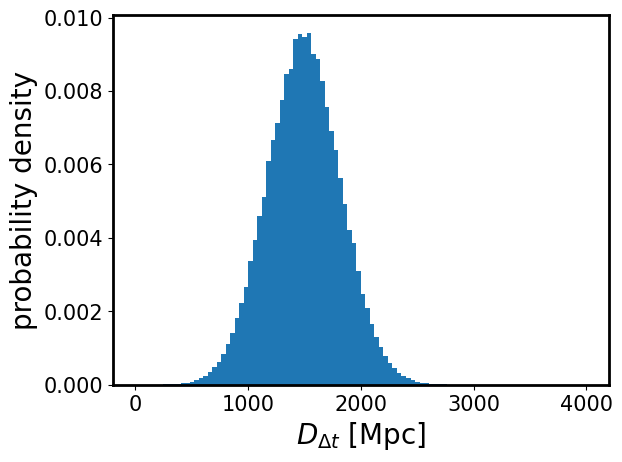

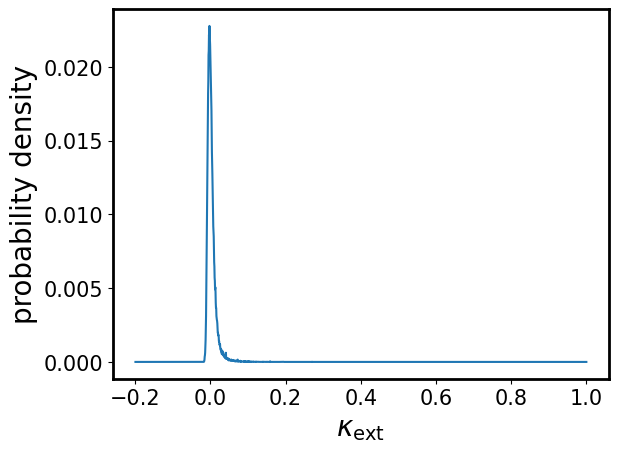

In [5]:
name = 'WGD2038-4008'
vel_disp_name = 'MUSE'

ddt_posterior_file = 'desj2038_pl_nokext_nokin_dt_weight.csv'

kappa_ext_file = 'kappahist_2038_measured_3innermask_nobeta_removehandpicked_zgap-1.0_-1.0_fiducial_120_gal_120_oneoverr_45_gal_45_zoverr_22.5_med_increments2_2_2_2_emptymsk.cat'

path2ddt = os.path.join(path2posteriors, name, ddt_posterior_file)
path2kappa = os.path.join(path2posteriors, name, kappa_ext_file)

# open ddt posterior
output = np.loadtxt(path2ddt, delimiter=',', skiprows=1)

ddt_samples = output[:, 0]
ddt_weights = output[:, 1]

plt.hist(ddt_samples, weights=ddt_weights, bins=100)
plt.xlabel(r"$D_{\Delta t}$ [Mpc]", fontsize=20)
plt.ylabel(r"probability density", fontsize=20)
plt.show()

# open kappa_ext posterior
kappa_pdf = np.loadtxt(path2kappa, usecols=[0], unpack=True)
kappa_min, kappa_max = -0.2, 1
kappa_bin_edges = np.linspace(start=kappa_min, stop=kappa_max, num=len(kappa_pdf)+1)
plt.plot(kappa_bin_edges[1:], kappa_pdf)
plt.xlabel(r"$\kappa_{\rm ext}$", fontsize=20)
plt.ylabel(r"probability density", fontsize=20)
plt.show()

if name in recompute_lenses:
    kwargs_posterior = process_posterior(name, ddt_samples, ddt_weights, kappa_pdf, kappa_bin_edges, num_sample_model, vel_disp_name=vel_disp_name)

    path2output = os.path.join(path2processed, name+'_' + anisotropy_model + '_processed.pkl')
    file = open(path2output, 'wb')
    pickle.dump(kwargs_posterior, file)
    file.close()


## WFI2033−4723

Discovery presented in [Morgan et al. 2014](https://ui.adsabs.harvard.edu/abs/2004AJ....127.2617M/abstract)

Imaging modeling presented in [Rusu et al. 2019](https://ui.adsabs.harvard.edu/abs/2019arXiv190509338R/abstract)

Velocity dispersion measurement from MUSE presented in [Rusu et al. 2019](https://ui.adsabs.harvard.edu/abs/2019arXiv190509338R/abstract)
with $250 \pm 10$ km/s statistical error and with systematics $250 \pm 19$ km/s.

New Measurement by JWST NIRSpec (Shajib, Knabel et al., in prep) with aperture averaged dispersion $210\pm 11$  km/s including statistical and systematic uncertainties with aperture 0.55"x0.55".

Time-delay measurement presented in [Bonvin et al. 2019](https://ui.adsabs.harvard.edu/abs/2019A%26A...629A..97B/abstract)

LOS analysis presented in [Rusu et al. 2019](https://ui.adsabs.harvard.edu/abs/2019arXiv190509338R/exportcitation)

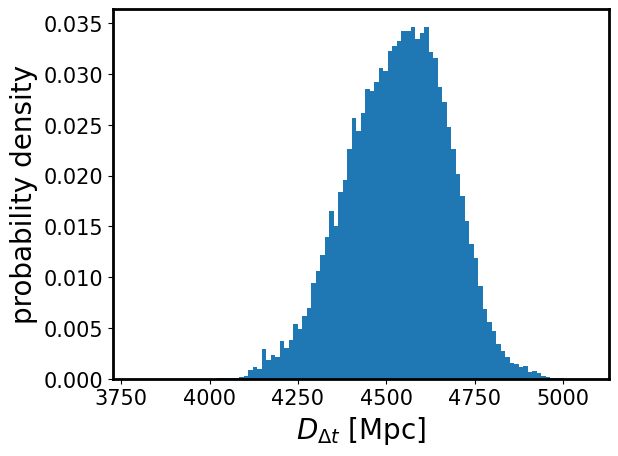

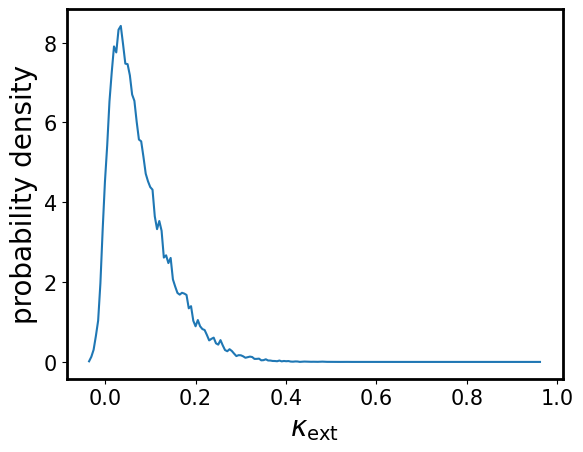

[]


In [6]:
name = 'WFI2033-4723'

vel_disp_name='JWST_NIRSpec'

ddt_posterior_file = 'wfi2033_pl_dt_nokext.dat'
kappa_ext_file = 'wfi2033_kext_bic_pdf.dat'
path2ddt = os.path.join(path2posteriors, name, ddt_posterior_file)
path2kappa = os.path.join(path2posteriors, name, kappa_ext_file)

# open ddt posterior
output = np.loadtxt(path2ddt, delimiter=',', skiprows=1)
# open kappa_ext posterior
ddt_samples = output[:, 0]
ddt_weights = output[:, 1]

plt.hist(ddt_samples, weights=ddt_weights, bins=100)
plt.xlabel(r"$D_{\Delta t}$ [Mpc]", fontsize=20)
plt.ylabel(r"probability density", fontsize=20)
plt.show()


output = np.loadtxt(path2kappa, delimiter=',', skiprows=1)
kappa_sample = output[:, 0]
kappa_weights = weights=output[:, 1]

kappa_pdf, kappa_bin_edges = np.histogram(kappa_sample, weights=kappa_weights, bins=200, density=True)
plt.plot(kappa_bin_edges[1:], kappa_pdf)
plt.xlabel(r"$\kappa_{\rm ext}$", fontsize=20)
plt.ylabel(r"probability density", fontsize=20)
plt.show()

if name in recompute_lenses:
    kwargs_posterior = process_posterior(name, ddt_samples, ddt_weights, kappa_pdf, kappa_bin_edges, num_sample_model,
                                         vel_disp_name=vel_disp_name)

    path2output = os.path.join(path2processed, name+'_' + anisotropy_model + '_processed.pkl')
    file = open(path2output, 'wb')
    pickle.dump(kwargs_posterior, file)
    file.close()
else:
    print(recompute_lenses)

## SDSS1206+4332

Discovery presented in [Oguri et al. 2005](https://ui.adsabs.harvard.edu/abs/2005ApJ...622..106O/abstract)

Imaging modeling presented in [Birrer et al. 2019](https://ui.adsabs.harvard.edu/abs/2019MNRAS.484.4726B/abstract)

Velocity dispersion measurement from Keck-DEIMOS presented in [Agnello et al. 2016](https://ui.adsabs.harvard.edu/abs/2016MNRAS.458.3830A/abstract)
withg $290 \pm 30$ km/s including systematics.

New JWST integrated velocity dispersion measurement $295 \pm 9.5$ km/s including systematics.


Time-delay measurement presented in [Eulares et al. 2013](https://ui.adsabs.harvard.edu/abs/2013A%26A...553A.121E/abstract)

LOS analysis presented in [Birrer et al. 2019](https://ui.adsabs.harvard.edu/abs/2019MNRAS.484.4726B/abstract)

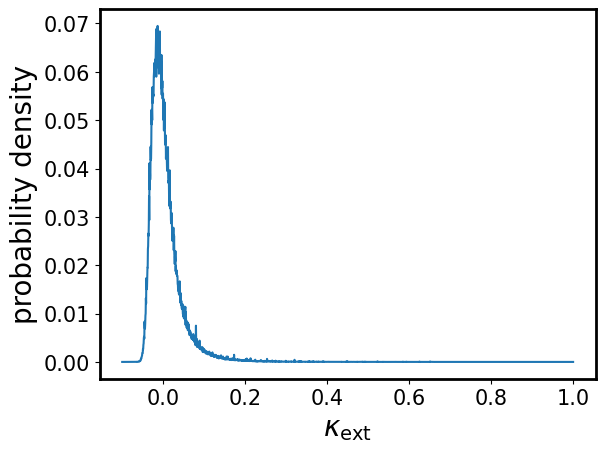

-0.004201773236016398 median kappa_ext
16924 len kappa_pert


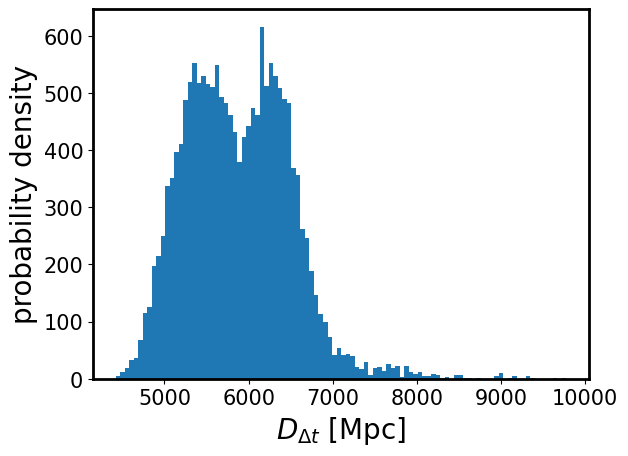

5845.569790766051 626.047197726063


In [7]:
name = 'SDSS1206+4332'
z_d = 0.745  # lens redshift; this is needed because the posterior products did not have this factor included

ddt_posterior_file = 'angular_diameter_pre_LOS_power_law.txt'

vel_disp_name='JWST_NIRSpec'

kappa_ext_file = 'kappahist_J1206_measured_5innermask_nobeta_zgap-1.0_-1.0_fiducial_120_gal_120_zoverr_45_gal_45_zoverr_24_med_increments4_4_4_4.cat'
path2kappa = os.path.join(path2posteriors, name, kappa_ext_file)
path2ddt = os.path.join(path2posteriors, name, ddt_posterior_file)

# this is the convergence distribution used in Birrer et al. 2019


kappa_pdf = np.loadtxt(path2kappa)
kappa_bin_edges = np.linspace(start=-0.1, stop=1, num=len(kappa_pdf)+1)
plt.plot(kappa_bin_edges[1:], kappa_pdf)
plt.xlabel(r"$\kappa_{\rm ext}$", fontsize=20)
plt.ylabel(r"probability density", fontsize=20)
plt.show()

from hierarc.Util.distribution_util import PDFSampling
pdf = PDFSampling(pdf_array=kappa_pdf, bin_edges=kappa_bin_edges)
sample = pdf.draw(n=20000)
print(np.median(sample), 'median kappa_ext')

with open(path2ddt, 'rb') as f:
    out = pickle.load(f, encoding='latin1') 

#f = open(path2ddt)
#out = pickle.load(f, encoding='latin-1')  #
#f.close()
Dd_ds_dds_samples, D_d_samples, kappa_pert = out

print(len(kappa_pert), 'len kappa_pert')
# kappa_pert is to avoid double counting of mass already accounted in the external convergence estimation
Dd_ds_dds_samples /= (1 + kappa_pert)

ddt_samples = Dd_ds_dds_samples * (1 + z_d)
ddt_weights = None

ddt_samples = ddt_samples[ddt_samples > 0]
plt.hist(ddt_samples, weights=ddt_weights, bins=100)
plt.xlabel(r"$D_{\Delta t}$ [Mpc]", fontsize=20)
plt.ylabel(r"probability density", fontsize=20)
plt.show()
print(np.median(ddt_samples), np.std(ddt_samples))

if name in recompute_lenses:
    kwargs_posterior = process_posterior(name, ddt_samples, ddt_weights, kappa_pdf, kappa_bin_edges, num_sample_model, vel_disp_name=vel_disp_name)

    path2output = os.path.join(path2processed, name+'_' + anisotropy_model + '_processed.pkl')
    file = open(path2output, 'wb')
    pickle.dump(kwargs_posterior, file)
    file.close()

## DES0408-5354

Discovery presented in [Lin et al. 2017](https://ui.adsabs.harvard.edu/abs/2017ApJ...838L..15L/abstract)
and [Diehl et al. 2017](https://ui.adsabs.harvard.edu/abs/2017ApJS..232...15D/abstract)

Imaging modeling presented in [Shajib et al. 2020](https://ui.adsabs.harvard.edu/abs/2020MNRAS.tmp.1051S/abstract)

Velocity dispersion measurement from GEMINI, Magellan and MUSE presented in [Buckley-Geer et al. 2020](https://ui.adsabs.harvard.edu/abs/2020arXiv200312117B/abstract)
Data from Table 3 in [Shajib et al. 2020](https://ui.adsabs.harvard.edu/abs/2020MNRAS.tmp.1051S/abstract) without systematics and a covariant added systematic uncertainty of $\pm 17$ km/s (following [Shajib et al. 2020](https://ui.adsabs.harvard.edu/abs/2020MNRAS.tmp.1051S/abstract) without systematics).

MUSE data: $242.3 \pm 10.2$ (stat) $\pm 6.9$ (sys). $\pm 12.2$ (stat+sys). Superceeds GEMINI measurements.


Time-delay measurement presented in [Courbin et al. 2018](https://ui.adsabs.harvard.edu/abs/2018A%26A...609A..71C/abstract)

LOS analysis presented in [Buckley-Geer et al. 2020](https://ui.adsabs.harvard.edu/abs/2020arXiv200312117B/abstract)



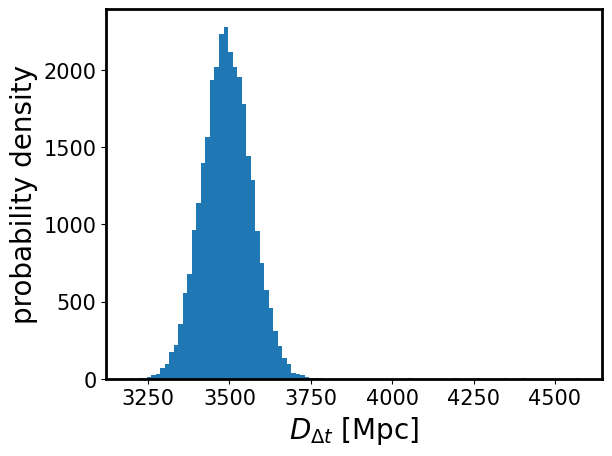

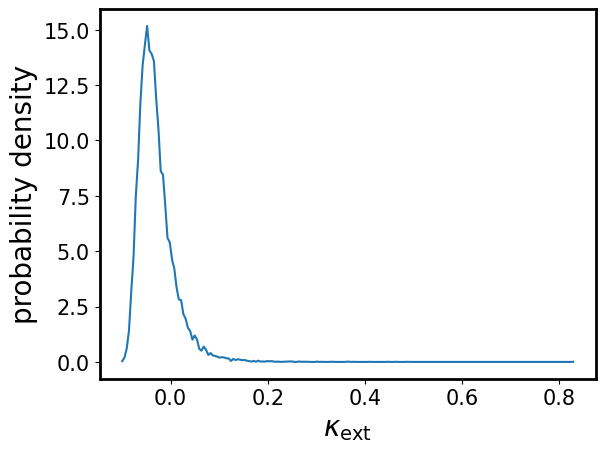

In [8]:
name = 'DES0408-5354'
vel_disp_name = "MUSE"

ddt_posterior_file = 'power_law_dist_post_no_kext.txt'
kappa_ext_file = 'kext_sampled.txt'
path2kappa = os.path.join(path2posteriors, name, kappa_ext_file)
path2ddt = os.path.join(path2posteriors, name, ddt_posterior_file)

# open ddt posterior
ddt_samples = np.loadtxt(path2ddt, delimiter=',', skiprows=1)
ddt_weights = None

plt.hist(ddt_samples, weights=ddt_weights, bins=100)
plt.xlabel(r"$D_{\Delta t}$ [Mpc]", fontsize=20)
plt.ylabel(r"probability density", fontsize=20)
plt.show()

# open kappa_ext posterior
kappa_sample = np.loadtxt(path2kappa, delimiter=',', skiprows=1)
kappa_weights = None

kappa_pdf, kappa_bin_edges = np.histogram(kappa_sample, weights=kappa_weights, bins=200, density=True)
plt.plot(kappa_bin_edges[1:], kappa_pdf)
plt.xlabel(r"$\kappa_{\rm ext}$", fontsize=20)
plt.ylabel(r"probability density", fontsize=20)
plt.show()

if name in recompute_lenses:
    kwargs_posterior = process_posterior(name, ddt_samples, ddt_weights, kappa_pdf, kappa_bin_edges, num_sample_model, vel_disp_name=vel_disp_name)

    path2output = os.path.join(path2processed, name+'_' + anisotropy_model + '_processed.pkl')
    file = open(path2output, 'wb')
    pickle.dump(kwargs_posterior, file)
    file.close()


## RXJ1131−1231

Discovery presented in [Sluse et al. 2003](https://ui.adsabs.harvard.edu/abs/2003A%26A...406L..43S/abstract)

HST imaging modeling presented in [Suyu et al. 2014](https://ui.adsabs.harvard.edu/abs/2014ApJ...788L..35S/abstract).
AO imaging modeling presented in [Chen et al. 2019](https://ui.adsabs.harvard.edu/abs/2019MNRAS.490.1743C/abstract)


Velocity dispersion measurement from Keck-LRIS  presented in [Suyu et al. 2013](https://ui.adsabs.harvard.edu/abs/2013ApJ...766...70S/abstract)
withg $323 \pm 20$ km/s including systematics.


Time-delay measurement presented in [Tewes et al. 2012](https://ui.adsabs.harvard.edu/abs/2012Msngr.150...49T/abstract)

LOS analysis presented in [Suyu et al. 2013](https://ui.adsabs.harvard.edu/abs/2013ApJ...766...70S/abstract)

Independent re-analysis by [Birrer et al. 2016](https://ui.adsabs.harvard.edu/abs/2016JCAP...08..020B/abstract)

New KCWI data by [Shajib et al. 2023](https://ui.adsabs.harvard.edu/abs/2023A%26A...673A...9S/abstract)

JWST IFU data to be presented in Shajib et al. 2025. (in prep)

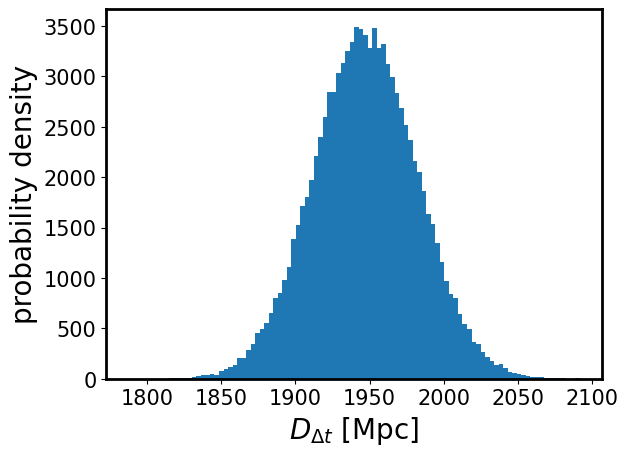

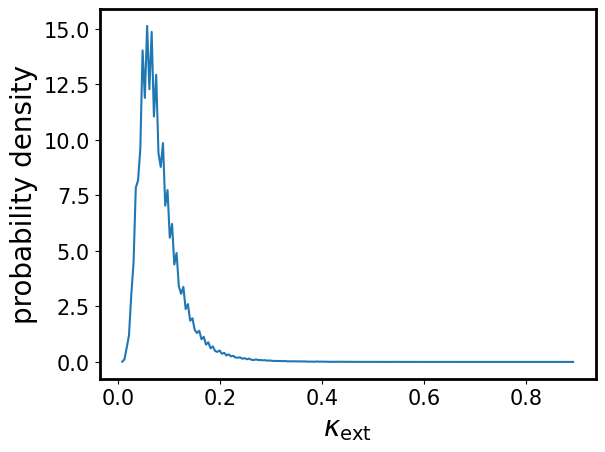

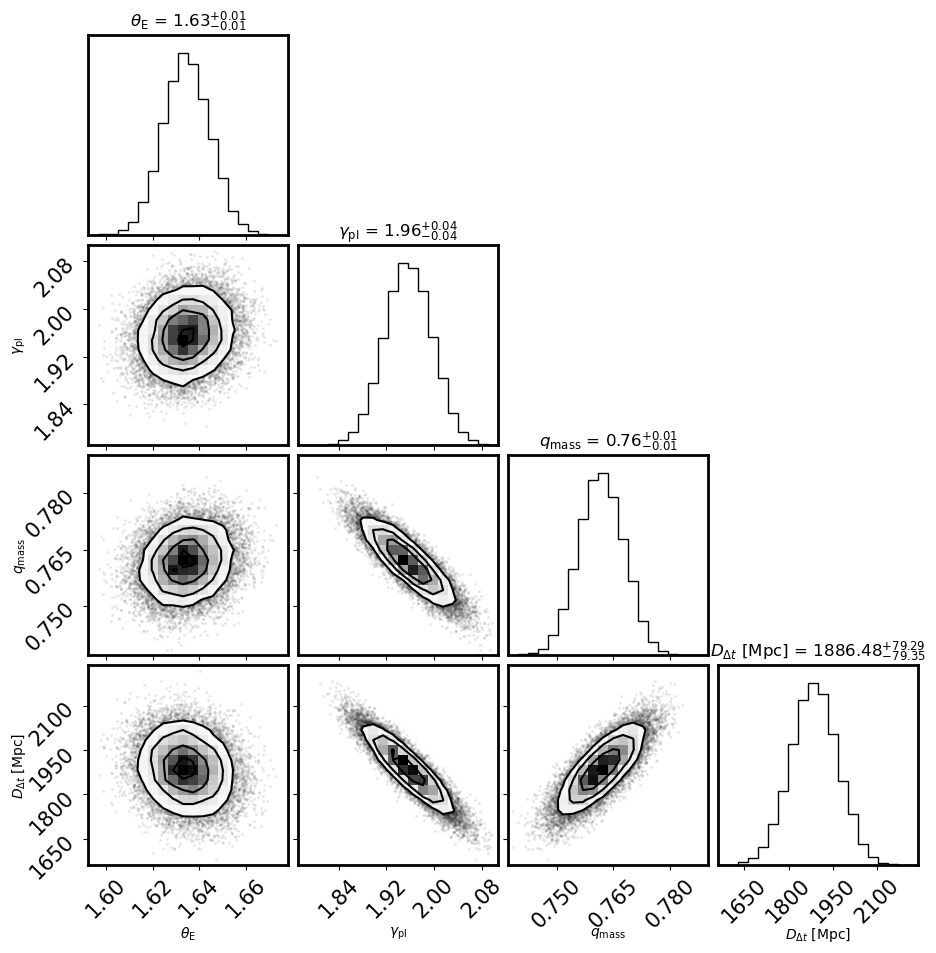

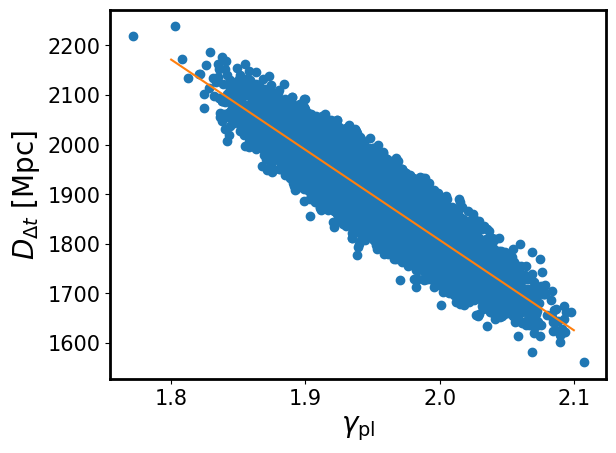

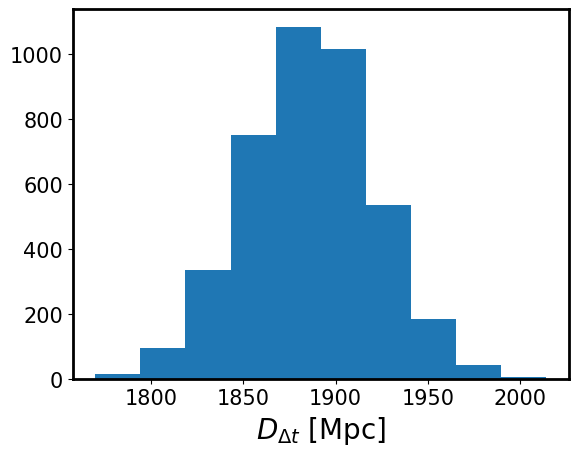

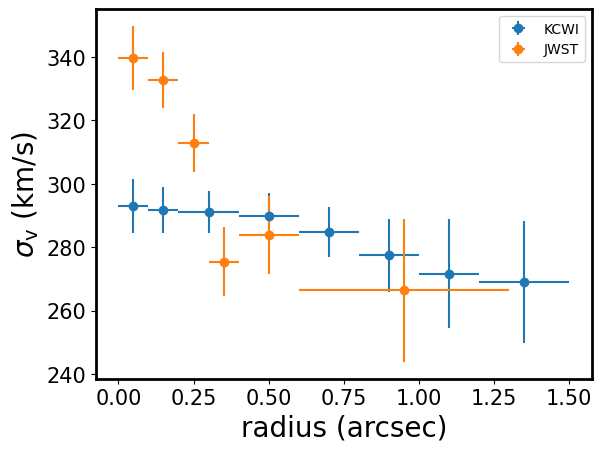

In [9]:
name = 'RXJ1131-1231'

ddt_posterior_file = 'rxj_powerlaw_Ddt.dat'
kappa_ext_file = 'kappa_powerlaw_rxj.dat'
ifu_kin_kcwi_file = 'rxj1131_kcwi_v_rms_binned.h5'
ifu_kin_jwst_file = 'rxj1131_jwst_v_rms_binned.h5'

path2kappa = os.path.join(path2posteriors, name, kappa_ext_file)
path2ddt = os.path.join(path2posteriors, name, ddt_posterior_file)
path2ifukin_kcwi = os.path.join(path2posteriors, name, ifu_kin_kcwi_file)
path2ifukin_jwst = os.path.join(path2posteriors, name, ifu_kin_jwst_file)

# open ddt posterior
ddt_samples = np.loadtxt(path2ddt, delimiter=',', skiprows=1)
ddt_samples = np.random.choice(ddt_samples, size=100000)  # we select 100'000 posteriors to keep the memory requirement lower
ddt_weights = None
plt.hist(ddt_samples, weights=ddt_weights, bins=100)
plt.xlabel(r"$D_{\Delta t}$ [Mpc]", fontsize=20)
plt.ylabel(r"probability density", fontsize=20)
plt.show()


# open kappa_ext posterior
kappa_sample = np.loadtxt(path2kappa, delimiter=',', skiprows=1)
kappa_weights = None


kappa_pdf, kappa_bin_edges = np.histogram(kappa_sample, weights=kappa_weights, bins=200, density=True)
plt.plot(kappa_bin_edges[1:], kappa_pdf)
plt.xlabel(r"$\kappa_{\rm ext}$", fontsize=20)
plt.ylabel(r"probability density", fontsize=20)
plt.show()


# import posteriors
rxj_path = os.path.join(dir_path, 'TDCOSMO_data/RXJ1131-1231')
posterior_path = os.path.join(rxj_path, 'rxj1131_glee_power_law_lens_model_posterior.txt')

rxj_posteriors = np.loadtxt(posterior_path)

corner.corner(rxj_posteriors, show_titles=True, labels=[r'$\theta_{\rm E}$', r'$\gamma_{\rm pl}$', r'$q_{\rm mass}$', r'$D_{\Delta t}$ [Mpc]'])
plt.show()



# The `rxj1131_glee_power_law_lens_model_posterior.txt` file contains the weighted-combined power-law model chain for RXJ1131 from Suyu et al. (2013) (cf. black contours of Fig 3 therein). The columns are $\theta_{\rm E}$ [arcsec], $\gamma$, $q_{\rm m}$, and $D_{\Delta t}$ [Mpc] (without $\kappa_{\rm ext}$ incorporated).

#plot gamma_pl vs Ddt

gamma_pl = rxj_posteriors[:, 1]
ddt = rxj_posteriors[:, 3]
gamma_pl_mean = np.mean(gamma_pl)
ddt_mean = np.mean(ddt)
ddt_sigma = np.std(ddt)
gamma_pl_sigma = np.std(gamma_pl)

d2_posterior = np.vstack((gamma_pl, ddt))
cov = np.cov(d2_posterior)


x = np.linspace(start=1.8, stop=2.1, num=10)

gamma_pl_ddt_slope = cov[1, 0] / gamma_pl_sigma**2

y = (x - gamma_pl_mean) * gamma_pl_ddt_slope + ddt_mean

plt.plot(gamma_pl, ddt, 'o')
plt.plot(x, y, '-')
plt.ylabel(r'$D_{\Delta t}$ [Mpc]', fontsize=20)
plt.xlabel(r'$\gamma_{\rm pl}$', fontsize=20)

plt.show()


ddt_select = ddt[(gamma_pl > gamma_pl_mean - 0.01) & (gamma_pl < gamma_pl_mean + 0.01)]

ddt_select_std = np.std(ddt_select)
plt.hist(ddt_select)
plt.xlabel(r'$D_{\Delta t}$ [Mpc]', fontsize=20)
plt.show()







# open ifu kin values
import h5py as h5

with h5.File(path2ifukin_kcwi, 'r') as f:
    sigma_v_kcwi = f['binned_dispersion'][()]
    covariance_matrix_kcwi = f['covariance'][()]
    radial_bins_kcwi = f['radial_bins'][()]
    
plt.errorbar(x=(radial_bins_kcwi[:-1]+np.diff(radial_bins_kcwi)/2.), 
             y=sigma_v_kcwi, 
             xerr=np.diff(radial_bins_kcwi)/2.,
             yerr=np.sqrt(np.diag(covariance_matrix_kcwi)),
             ls='None', marker='o', label='KCWI'
            )
with h5.File(path2ifukin_jwst, 'r') as f:
    sigma_v_jwst = f['binned_dispersion'][()]
    covariance_matrix_jwst = f['covariance'][()]
    radial_bins_jwst = f['radial_bins'][()]
    
plt.errorbar(x=(radial_bins_jwst[:-1]+np.diff(radial_bins_jwst)/2.), 
             y=sigma_v_jwst, 
             xerr=np.diff(radial_bins_jwst)/2.,
             yerr=np.sqrt(np.diag(covariance_matrix_jwst)),
             ls='None', marker='o', label='JWST'
            )
plt.legend()

plt.xlabel('radius (arcsec)', fontsize=20)
plt.ylabel(r'$\sigma_{\rm v}$ (km/s)', fontsize=20)
plt.show()

n_data = len(sigma_v_kcwi) + len(sigma_v_jwst)
error_cov_measurement = np.zeros((n_data, n_data))
error_cov_measurement[0:len(sigma_v_kcwi), 0:len(sigma_v_kcwi)] += covariance_matrix_kcwi
error_cov_measurement[len(sigma_v_kcwi):, len(sigma_v_kcwi):] += covariance_matrix_jwst


sigma_v_combined = np.concatenate((sigma_v_kcwi, sigma_v_jwst))


kwargs_aperture_kcwi = {'aperture_type': 'IFU_shells',
                        'r_bins': radial_bins_kcwi, 'center_ra': 0, 'center_dec': 0}
kwargs_aperture_jwst = {'aperture_type': 'IFU_shells',
                        'r_bins': radial_bins_jwst, 'center_ra': 0, 'center_dec': 0}
kwargs_seeing_kcwi = {'psf_type': 'GAUSSIAN', 'fwhm': 0.96}
kwargs_seeing_jwst = {'psf_type': 'GAUSSIAN', 'fwhm': 0.1476}


kwargs_aperture_list = [kwargs_aperture_kcwi, kwargs_aperture_jwst]
kwargs_seeing_list = [kwargs_seeing_kcwi, kwargs_seeing_jwst]



if name in recompute_lenses:
    row = read_lens_dict(name)

    z_lens = float(row['z_lens'])
    kwargs = {'z_lens': float(row['z_lens']), 'z_source': float(row['z_source']),
                          'r_eff': float(row['r_eff']), 'r_eff_error': float(row['r_eff_error']),
                          'theta_E': float(row['theta_E']), 'theta_E_error': float(row['theta_E_error']),
                          'gamma': float(row['gamma']), 'gamma_error': float(row['gamma_error'])}
    # We are using different light profiles for the kinematics modeling of the KCWI and JWST data
    lens_light_model_list_kcwi, kwargs_lens_light_kcwi, MGE_light, kwargs_mge_light, phi_light, q_light, phi_mass, q_mass, r_eff = light_model_config(row, light_model_type='light_profile_F814W')
    lens_light_model_list_jwst, kwargs_lens_light_jwst, MGE_light, kwargs_mge_light, phi_light, q_light, phi_mass, q_mass, r_eff = light_model_config(row, light_model_type='light_profile_IR_F814W_stitched')

    #lens_light_model_list_combined = [lens_light_model_list_kcwi, lens_light_model_list_jwst]
    lens_light_model_list_combined = lens_light_model_list_kcwi  # currently assumes that both light profile types are identical in functional form
    kwargs_lens_light_combined = [kwargs_lens_light_kcwi, kwargs_lens_light_jwst]
                
    num_sample_model_ifu = 500
    gamma_pl_scaling_array = np.linspace(start=1.5, stop=2.5, num=5)
                
    ddt_kin = DdtKinConstraints(ddt_samples=ddt_samples, 
                            ddt_weights=ddt_weights,
                            sigma_v_measured=sigma_v_combined, 
                            sigma_v_error_cov_matrix=error_cov_measurement,
                            multi_observations=True,
                            multi_light_profile=True,
                            kwargs_aperture=kwargs_aperture_list, kwargs_seeing=kwargs_seeing_list, 
                            kwargs_numerics_galkin=kwargs_numerics_galkin, hernquist_approx=False,
                            anisotropy_model=anisotropy_model, kwargs_lens_light=kwargs_lens_light_combined, 
                            lens_light_model_list=lens_light_model_list_combined, MGE_light=MGE_light,
                            kwargs_mge_light=kwargs_mge_light, num_kin_sampling=2000, num_psf_sampling=500,
                            gamma_pl_scaling=gamma_pl_scaling_array,                
                            **kwargs)


    kwargs_posterior = ddt_kin.hierarchy_configuration(num_sample_model=num_sample_model_ifu)
    kwargs_posterior['name'] = name
    kwargs_posterior['kwargs_lens_properties'] = {'theta_E': float(row['theta_E']),
                                                              'gamma': float(row['gamma']),
                                                              'r_eff': float(row['r_eff']),
                                                              'q_light': q_light, 'phi_light': phi_light,
                                                              'q_mass': q_mass, 'phi_mass': phi_mass}
    kwargs_posterior = dict(**kwargs_posterior, **{'kde_kernel':'gaussian', 'bandwidth':20, 'nbins_hist':100})
    kwargs_posterior['kappa_pdf'] = kappa_pdf
    kwargs_posterior['kappa_bin_edges'] = kappa_bin_edges
                
    # replace Ddt sample with scaling with gamma_pl
    kwargs_posterior['ddt_samples'] = ddt_select  # narrow Ddt posterior around gamma_pl_pivot
    kwargs_posterior['gamma_pl_pivot'] = gamma_pl_mean
    kwargs_posterior['gamma_pl_ddt_slope'] = gamma_pl_ddt_slope
        
    # print(kwargs_posterior)
    path2output = os.path.join(path2processed, name+'_' + anisotropy_model + '_processed.pkl')
    file = open(path2output, 'wb')
    pickle.dump(kwargs_posterior, file)
    file.close()

## HE0435−1223

Discovery presented in [Wisotzki et al. 2002](https://ui.adsabs.harvard.edu/abs/2002A%26A...395...17W/abstract)


HST imaging modeling presented in [Wong et al. 2017](https://ui.adsabs.harvard.edu/abs/2017MNRAS.465.4895W/abstract).
AO imaging modeling presented in [Chen et al. 2019](https://ui.adsabs.harvard.edu/abs/2019MNRAS.490.1743C/abstract).

Velocity dispersion measurement from Keck-LRIS  presented in [Wong et al. 2017](https://ui.adsabs.harvard.edu/abs/2017MNRAS.465.4895W/abstract)
withg $222 \pm 15$ km/s including systematics.
Independent measurement by [Courbin et al. 2011](https://ui.adsabs.harvard.edu/abs/2011A%26A...536A..53C/abstract) with VLT in excellent agreement $222 \pm 34$ km/s.

New Measurement by JWST NIRSpec (Shajib, Knabel et al., in prep) with aperture averaged dispersion $226\pm 6$  km/s including statistical and systematic uncertainties with aperture 0.55"x0.55".

Time-delay measurement presented in [Bonvin et al. 2016](https://ui.adsabs.harvard.edu/abs/2016A%26A...585A..88B/abstract)

LOS analysis presented in [Rusu et al. 2017](https://ui.adsabs.harvard.edu/abs/2017MNRAS.467.4220R/abstract)

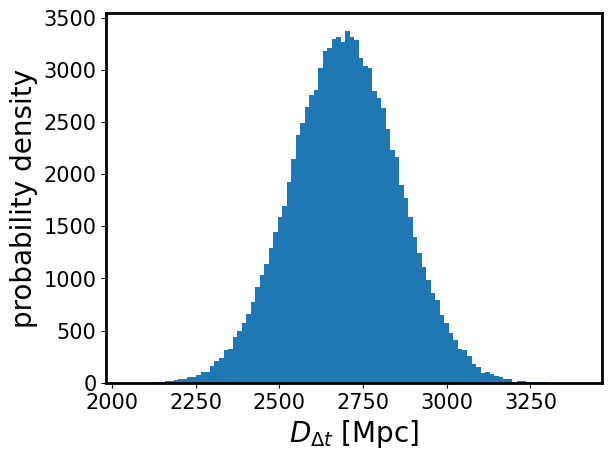

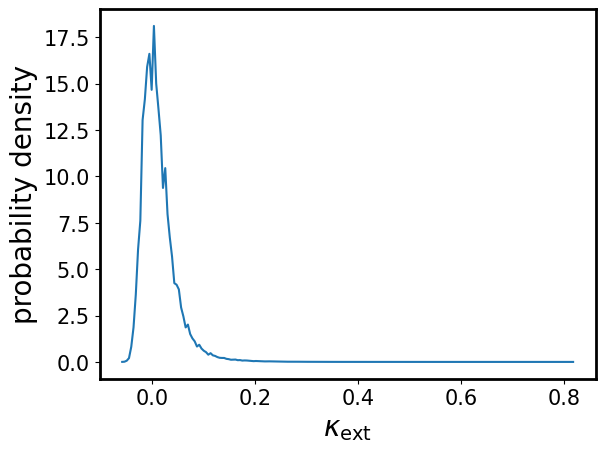

In [10]:
name = 'HE0435-1223'

vel_disp_name='JWST_NIRSpec'

ddt_posterior_file = 'he_powerlaw_Ddt.dat'
kappa_ext_file = 'kappa_powerlaw_he.dat'
path2kappa = os.path.join(path2posteriors, name, kappa_ext_file)
path2ddt = os.path.join(path2posteriors, name, ddt_posterior_file)

# open ddt posterior
ddt_samples = np.loadtxt(path2ddt, delimiter=',', skiprows=1)
ddt_samples = np.random.choice(ddt_samples, size=100000)  # we select 100'000 posteriors to keep the memory requirement lower


ddt_weights = None

# open kappa_ext posterior
kappa_sample = np.loadtxt(path2kappa, delimiter=',', skiprows=1)
kappa_weights = None

plt.hist(ddt_samples, weights=ddt_weights, bins=100)
plt.xlabel(r"$D_{\Delta t}$ [Mpc]", fontsize=20)
plt.ylabel(r"probability density", fontsize=20)
plt.show()


kappa_pdf, kappa_bin_edges = np.histogram(kappa_sample, weights=kappa_weights, bins=200, density=True)
plt.plot(kappa_bin_edges[1:], kappa_pdf)
plt.xlabel(r"$\kappa_{\rm ext}$", fontsize=20)
plt.ylabel(r"probability density", fontsize=20)
plt.show()

if name in recompute_lenses:
    kwargs_posterior = process_posterior(name, ddt_samples, ddt_weights, kappa_pdf, kappa_bin_edges, num_sample_model,
                                         vel_disp_name=vel_disp_name)

    path2output = os.path.join(path2processed, name+'_' + anisotropy_model + '_processed.pkl')
    file = open(path2output, 'wb')
    pickle.dump(kwargs_posterior, file)
    file.close()

## PG1115+080


Discovery presented in [Weymann et al. 1980](https://ui.adsabs.harvard.edu/abs/1980Natur.285..641W/abstract).


AO imaging modeling presented in [Chen et al. 2019](https://ui.adsabs.harvard.edu/abs/2019MNRAS.490.1743C/abstract).

Velocity dispersion measurement from Keck-LRIS  presented in [Tonry et al. 1998](https://ui.adsabs.harvard.edu/abs/1998AJ....115....1T/abstract)
with $281 \pm 25$ km/s.

New Measurement by JWST NIRSpec (Shajib, Knabel et al., in prep) with aperture averaged dispersion $235\pm 7$  km/s including statistical and systematic uncertainties with aperture 0.55"x0.55".

Time-delay measurement presented in [Bonvin et al. 2018](https://ui.adsabs.harvard.edu/abs/2018A%26A...616A.183B/abstract).

LOS analysis presented in [Chen et al. 2019](https://ui.adsabs.harvard.edu/abs/2019MNRAS.490.1743C/abstract).


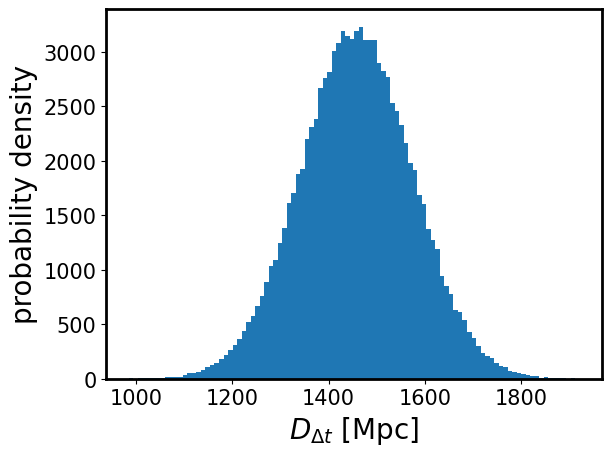

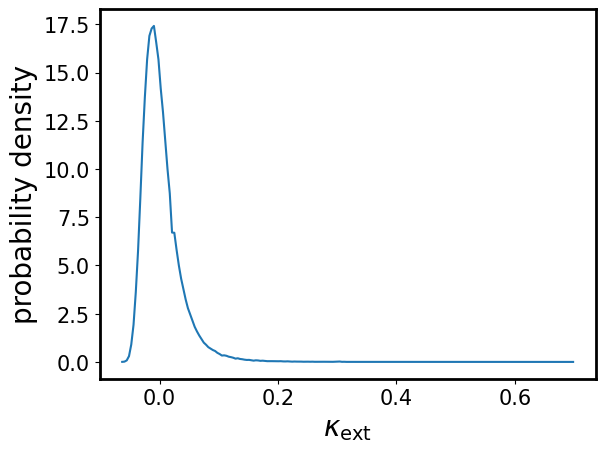

In [11]:
name = 'PG1115+080'

vel_disp_name='JWST_NIRSpec'

ddt_posterior_file = 'pg_powerlaw_Ddt.dat'
kappa_ext_file = 'kappa_powerlaw_pg.dat'
path2kappa = os.path.join(path2posteriors, name, kappa_ext_file)
path2ddt = os.path.join(path2posteriors, name, ddt_posterior_file)

# open ddt posterior
ddt_samples = np.loadtxt(path2ddt, delimiter=',', skiprows=1)
ddt_samples = np.random.choice(ddt_samples, size=100000)  # we select 100'000 posteriors to keep the memory requirement lower
ddt_weights = None

# open kappa_ext posterior
kappa_sample = np.loadtxt(path2kappa, delimiter=',', skiprows=1)
kappa_weights = None

plt.hist(ddt_samples, weights=ddt_weights, bins=100)
plt.xlabel(r"$D_{\Delta t}$ [Mpc]", fontsize=20)
plt.ylabel(r"probability density", fontsize=20)
plt.show()


kappa_pdf, kappa_bin_edges = np.histogram(kappa_sample, weights=kappa_weights, bins=200, density=True)
plt.plot(kappa_bin_edges[1:], kappa_pdf)
plt.xlabel(r"$\kappa_{\rm ext}$", fontsize=20)
plt.ylabel(r"probability density", fontsize=20)
plt.show()


if name in recompute_lenses:
    kwargs_posterior = process_posterior(name, ddt_samples, ddt_weights, kappa_pdf, kappa_bin_edges, num_sample_model,
                                         vel_disp_name=vel_disp_name)

    path2output = os.path.join(path2processed, name+'_' + anisotropy_model + '_processed.pkl')
    file = open(path2output, 'wb')
    pickle.dump(kwargs_posterior, file)
    file.close()

## B1606+656


Discovery in the Cosmic Lens All-Sky Survey (CLASS) presented in [Myers et al. 1995](https://ui.adsabs.harvard.edu/abs/1995ApJ...447L...5M/abstract).


Imaging modeling presented in [Suyu et al. 2009](https://ui.adsabs.harvard.edu/abs/2009ApJ...691..277S/abstract) and [Suyu et al. 2010](https://ui.adsabs.harvard.edu/abs/2010ApJ...711..201S/abstract).

Velocity dispersion measurement from Keck-LRIS presented in [Suyu et al. 2010](https://ui.adsabs.harvard.edu/abs/2010ApJ...711..201S/abstract).
withg $260$ km/s. Statistical uncertainty is $ \pm 7.7$km/s with a spread of $\pm 13$km/s depending on wavelenght and stellar template solution. Joint uncertainty is $260 \pm 15$km/s.
Previous measurement by [Koopmans et al. 2003](https://ui.adsabs.harvard.edu/abs/2003ApJ...599...70K/abstract) with $247 \pm 35$ km/s with ESI on Keck-II.

New Measurement by JWST NIRSpec (Shajib, Knabel et al., in prep) with aperture averaged dispersion
$304 \pm 11$ km/s including statistical and systematic uncertainties with aperture 0.55"x0.55".

Time-delay measurement presented in [Fassnacht et al. 1999](https://ui.adsabs.harvard.edu/abs/1999ApJ...527..498F/abstract),
[Fassnacht et al. 2002](https://ui.adsabs.harvard.edu/abs/2002ApJ...581..823F/abstract).

LOS analysis presented in [Suyu et al. 2010](https://ui.adsabs.harvard.edu/abs/2010ApJ...711..201S/abstract).

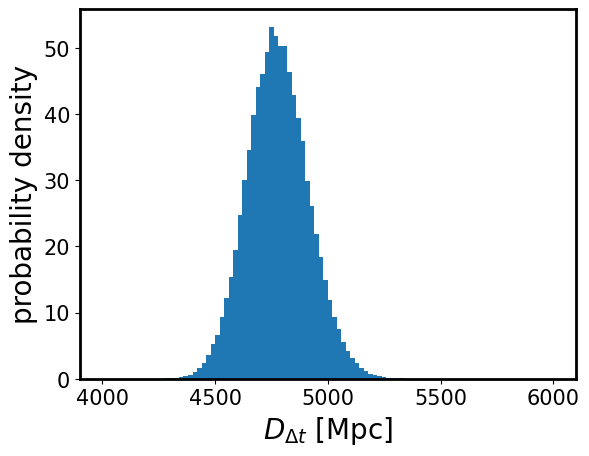

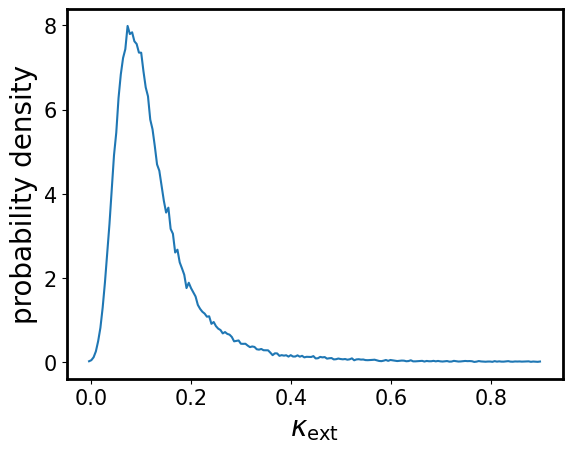

In [12]:
name = 'B1608+656'

ddt_posterior_file = 'B1608_Dtmod_n5e5.dat'
kappa_ext_file = 'B1608_kext.txt'
path2kappa = os.path.join(path2posteriors, name, kappa_ext_file)
path2ddt = os.path.join(path2posteriors, name, ddt_posterior_file)

# open ddt posterior
# wht, Dt^mod, gamma', kappa_ext
output = np.loadtxt(path2ddt, delimiter='\t', skiprows=1)
ddt_samples = output[:, 1]
ddt_weights = output[:, 0]

vel_disp_name='JWST_NIRSpec'

# open kappa_ext posterior
kappa_sample = np.loadtxt(path2kappa)
kappa_weights = None

plt.hist(ddt_samples, weights=ddt_weights, bins=100)
plt.xlabel(r"$D_{\Delta t}$ [Mpc]", fontsize=20)
plt.ylabel(r"probability density", fontsize=20)
plt.show()


kappa_pdf, kappa_bin_edges = np.histogram(kappa_sample, weights=kappa_weights, bins=200, density=True)
plt.plot(kappa_bin_edges[1:], kappa_pdf)
plt.xlabel(r"$\kappa_{\rm ext}$", fontsize=20)
plt.ylabel(r"probability density", fontsize=20)
plt.show()

if name in recompute_lenses:
    kwargs_posterior = process_posterior(name, ddt_samples, ddt_weights, kappa_pdf, kappa_bin_edges, num_sample_model,
                                         vel_disp_name=vel_disp_name)

    path2output = os.path.join(path2processed, name+'_' + anisotropy_model + '_processed.pkl')
    file = open(path2output, 'wb')
    pickle.dump(kwargs_posterior, file)
    file.close()



## Sampling individual chains and joint constraints to reproduce H0LiCOW results


In [ ]:

lenses_test_list = ['B1608+656', 'RXJ1131-1231', 'HE0435-1223', 'SDSS1206+4332', 'WFI2033-4723', 'PG1115+080', 'DES0408-5354', 'WGD2038-4008']


num_distribution_draw = 200

n_walkers = 100
n_run = 100  # 200
n_burn = 100  # 400


tdcosmo_posterior_list = []
for tdcosmo_lens in TDCOSMO_lenses:
#for tdcosmo_lens in lenses_test_list:
    td_cosmo_file_name = os.path.join(path2processed, tdcosmo_lens+'_' + anisotropy_model + '_processed.pkl')
    file = open(td_cosmo_file_name, 'rb')
    posterior = pickle.load(file)
    file.close()
    print(tdcosmo_lens)
    print(posterior['likelihood_type'])
    
    posterior['num_distribution_draws'] = num_distribution_draw
    posterior['error_cov_measurement'] = np.array(posterior['error_cov_measurement'], dtype='float')
    theta_E, r_eff = properties(tdcosmo_lens)
    posterior['lambda_scaling_property'] = r_eff/theta_E - 1
    tdcosmo_posterior_list.append(posterior)
    # This bug was fixed after unblinding
    posterior['kwargs_los_individual'] = {'bin_edges': posterior['kappa_bin_edges'], 'pdf_array': posterior['kappa_pdf']}
    posterior['los_distribution_individual'] = 'PDF'
    del posterior['kappa_bin_edges'], posterior['kappa_pdf']


file = open(os.path.join(path2processed, 'tdcosmo2025_likelihood_processed_'+anisotropy_model+'_.pkl'), 'wb')
pickle.dump(tdcosmo_posterior_list, file)
file.close()
    

B1608+656
DdtHistKin
RXJ1131-1231
DdtHistKin
HE0435-1223
DdtHistKin
SDSS1206+4332
DdtHistKin
WFI2033-4723
DdtHistKin
PG1115+080
DdtHistKin
DES0408-5354
DdtHistKin
WGD2038-4008
DdtHistKin


B1608+656
RXJ1131-1231
HE0435-1223
SDSS1206+4332
WFI2033-4723
PG1115+080
DES0408-5354
WGD2038-4008
0.03338564684482718 0.017687654514416794
0.033385646844827185 0.07073253410309474


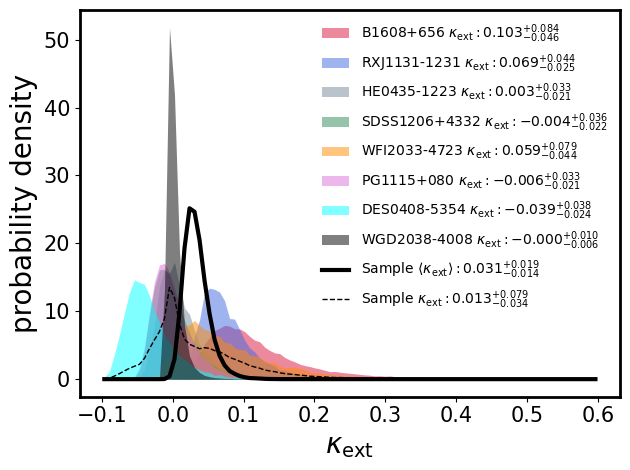

In [14]:
# external convergence distributions
from hierarc.Util.distribution_util import PDFSampling
alpha_kappa = 0.5
percentiles = [16, 50, 84]
quantiles = [0.16, 0.5, 0.84]
colors = ["crimson", "royalblue", "lightslategrey", "seagreen", "darkorange", "orchid", "cyan",  "black"]
title = r"${{{0}}}_{{-{1}}}^{{+{2}}}$"
fmt = "{{0:{0}}}".format(".3f").format
fmt_ddt = "{{0:{0}}}".format(".0f").format
fmt2 = "{{0:{0}}}".format(".2f").format
fmt3 = "{{0:{0}}}".format(".3f").format

exclude_name = []

kappa_pdf_list = []
kappa_name_list = []
for tdcosmo_lens in TDCOSMO_lenses:
#for tdcosmo_lens in lenses_test_list:

    td_cosmo_file_name = os.path.join(path2processed, tdcosmo_lens+'_' + anisotropy_model + '_processed.pkl')
    file = open(td_cosmo_file_name, 'rb')
    posterior = pickle.load(file)
    file.close()
    
    if posterior['name'] in exclude_name:
        pass
    else:
        print(posterior['name'])
        ddt_samples = posterior['ddt_samples']
        ddt_weights = posterior['ddt_weights']
        pcs = corner.quantile(ddt_samples, q=quantiles, weights=ddt_weights)
        #txt = title.format(fmt_ddt(pcs[1]), fmt_ddt(pcs[1]-pcs[0]), fmt_ddt(pcs[2]-pcs[1]))
        #print(txt)
        kappa_name_list.append(posterior['name'])
        kappa_pdf_list.append(PDFSampling(bin_edges=posterior['kappa_bin_edges'], pdf_array=posterior['kappa_pdf']))

kappa_bins = np.linspace(start=-0.1, stop=0.6, num=100)    
kappa_samples_list = []
for i, pdf in enumerate(kappa_pdf_list):
    kappa_samples = pdf.draw(n=100000)
    kappa_samples_list.append(kappa_samples)
    pcs = np.percentile(kappa_samples, q=percentiles)
    txt = r'$\kappa_{\rm ext}: $' + title.format(fmt(pcs[1]), fmt(pcs[1]-pcs[0]), fmt(pcs[2]-pcs[1]))
    h, be = np.histogram(kappa_samples, bins=kappa_bins, density=True)
    xs = [(b+be[ind+1])/2. for ind, b in enumerate(be[:-1])]
    plt.plot(xs, h, alpha=0.5, color=colors[i], linewidth=0.0)
    plt.fill_between(xs, h, alpha=0.5, color=colors[i], linewidth=0.0, label=kappa_name_list[i] + ' ' + txt)

    # add the values
    
    #plt.annotate(txt, xy=(0.0, 0.0), xytext=(0.02, 0.9-0.085*i), xycoords='axes fraction',
    #                 fontsize=16, color=colors[i])
    
    
    #plt.hist(kappa_samples, bins=kappa_bins, label=kappa_name_list[i], alpha=alpha_kappa, density=True, color=colors[i])
    

kappa_samples_list = np.array(kappa_samples_list)
kappa_means = np.mean(kappa_samples_list, axis=0)
print(np.mean(kappa_means), np.std(kappa_means))

pcs = np.percentile(kappa_means, q=percentiles)
txt = r'$\langle\kappa_{\rm ext}\rangle: $' + title.format(fmt(pcs[1]), fmt(pcs[1] - pcs[0]), fmt(pcs[2] - pcs[1]))

h, be = np.histogram(kappa_means, bins=kappa_bins, density=True)
xs = [(b+be[ind+1])/2. for ind, b in enumerate(be[:-1])]
plt.plot(xs, h, alpha=1.0, color=colors[-1], linewidth=3.0, label=r'Sample ' + txt)

kappa_samples_joint = kappa_samples_list.ravel()
print(np.mean(kappa_samples_joint), np.std(kappa_samples_joint))
pcs = np.percentile(kappa_samples_joint, q=percentiles)
txt = r'$\kappa_{\rm ext}: $' + title.format(fmt(pcs[1]), fmt(pcs[1] - pcs[0]), fmt(pcs[2] - pcs[1]))

h, be = np.histogram(kappa_samples_joint, bins=kappa_bins, density=True)
xs = [(b+be[ind+1])/2. for ind, b in enumerate(be[:-1])]
plt.plot(xs, h, alpha=1.0, color=colors[-1], linewidth=1.0, linestyle='--', label=r'Sample ' + txt)


plt.legend(frameon=False)
plt.xlabel(r"$\kappa_{\rm ext}$", fontsize=20)
plt.ylabel("probability density", fontsize=20)
plt.tight_layout()
#plt.savefig('/Users/sibirrer/Science/Projects/TDCOSMO/hierarchy_paper/Figures/kappa_ext_tdcosmo.pdf')
plt.show()


In [15]:
cosmology = 'FLCDM'  # available models: 'FLCDM', "FwCDM", "w0waCDM", "oLCDM"
# parameters are: 'h0', 'om', 'ok', 'w', 'w0', 'wa'

log_scatter = False  # flat prior in log space

# there is also the option to sample the post-newtonian parameter gamma_ppn

anisotropy_parameterization = 'TAN_RAD' # parameter sampled for the constant anisotropy model, supported types are ['TAN_RAD', 'beta']


beta_inf_min, beta_inf_max = 0, 1
if anisotropy_model == 'OM':
    a_ani_min, a_ani_max, a_ani_mean = 0.1, 5, 1
elif anisotropy_model == 'const':
    if anisotropy_parameterization == 'TAN_RAD':
        a_ani_min, a_ani_max, a_ani_mean = 0.87, 1.12, 1
    else:
        a_ani_min, a_ani_max, a_ani_mean = -0.31, 0.38, 0
elif anisotropy_model == 'GOM':
    a_ani_min, a_ani_max, a_ani_mean = 0.1, 5, 1
else:
    raise ValueError('invalid anisotropy model')


kwargs_lower_cosmo = {'h0': 0, 'om': 0.05}
kwargs_lower_lens = {'lambda_mst': 0.5, 'lambda_mst_sigma': 0.001, 'kappa_ext': -0.1, 'kappa_ext_sigma': 0., 
                     'lambda_ifu': 0.5, 'lambda_ifu_sigma': 0.001, 'alpha_lambda': -1,
                     'gamma_pl_list': np.ones(10) * 1.5}
kwargs_lower_kin = {'a_ani': a_ani_min, 'a_ani_sigma': 0.01, 'beta_inf': beta_inf_min, 'beta_inf_sigma': 0.001, 'sigma_v_sys_error': 0.01}

kwargs_upper_cosmo = {'h0': 150, 'om': 0.5}
kwargs_upper_lens = {'lambda_mst': 1.5, 'lambda_mst_sigma': .5, 'kappa_ext': 0.5, 'kappa_ext_sigma': 0.5, 
                     'lambda_ifu': 1.5, 'lambda_ifu_sigma': 0.5, 'alpha_lambda': 1,
                     'gamma_pl_list': np.ones(10) * 2.5}
kwargs_upper_kin = {'a_ani': a_ani_max, 'a_ani_sigma': 1. ,'beta_inf': beta_inf_max, 'beta_inf_sigma': 1, 'sigma_v_sys_error': 0.5}

# these values are held fixed throughout the entire sampling (optinal to add here)
kwargs_fixed_cosmo = {'om': 0.30}
kwargs_fixed_lens = {'lambda_mst': 1.}

# for the 'GOM' model is beta_inf should be free or fixed=1
kwargs_fixed_kin = {'a_ani': 1}


kwargs_mean_start = {'kwargs_cosmo': {'h0': 70, 'om': 0.3},
                     'kwargs_lens': {'lambda_mst': 1., 'lambda_mst_sigma': .05, 'lambda_ifu': 1, 'lambda_ifu_sigma': 0.05, 
                                     'alpha_lambda': 0, 'gamma_pl_list': np.ones(10) * 2},
                     'kwargs_kin': {'a_ani': a_ani_mean, 'a_ani_sigma': 0.1, 'beta_inf': 0.8, 'beta_inf_sigma': 0.1, 'sigma_v_sys_error': 0.05}}

kwargs_sigma_start = {'kwargs_cosmo': {'h0': 10, 'om': 0.1},
                     'kwargs_lens': {'lambda_mst': .1, 'lambda_mst_sigma': .05, 'lambda_ifu': 0.1, 'lambda_ifu_sigma': 0.05, 
                                     'alpha_lambda': 0.1, 'gamma_pl_list': np.ones(10) * 0.1},
                     'kwargs_kin': {'a_ani': 0.3, 'a_ani_sigma': 0.1, 'beta_inf': 0.5, 'beta_inf_sigma': 0.1, 'sigma_v_sys_error': 0.05}}


class CustomPrior(object):
    def __init__(self, om_prior=True, log_scatter=False):
        self._om_prior = om_prior
        self._log_scatter = log_scatter
        self.om_mean = 0.298
        self.sigma_om = 0.022
        
    def __call__(self, kwargs_cosmo, kwargs_lens, kwargs_kin):
        return self.log_likelihood(kwargs_cosmo, kwargs_lens, kwargs_kin)
    
    def log_likelihood(self, kwargs_cosmo, kwargs_lens, kwargs_kin):

        logL = 0
        # a prior on Omega_m helps in constraining the MST parameter as the kinematics becomes less cosmology dependent...
        if self._om_prior is True:
            om = kwargs_cosmo.get('om', self.om_mean)
            logL += -(om - self.om_mean)**2 / self.sigma_om**2 / 2
        if self._log_scatter is True:
            lambda_mst_sigma = kwargs_lens.get('lambda_mst_sigma', 1)
            logL += np.log(1/lambda_mst_sigma)
            lambda_ifu_sigma = kwargs_lens.get('lambda_ifu_sigma', 1)
            logL += np.log(1/lambda_ifu_sigma)
            a_ani_sigma = kwargs_kin.get('a_ani_sigma', 1)
            logL += np.log(1/a_ani_sigma)
            sigma_v_sys_error = kwargs_kin.get('sigma_v_sys_error', 1)
            logL += np.log(1/sigma_v_sys_error)
            
        a_ani = kwargs_kin.get('a_ani', 1)
        logL += np.log(1/a_ani)
        return logL
    
kwargs_bounds = {'kwargs_lower_cosmo': kwargs_lower_cosmo,
                'kwargs_lower_lens': kwargs_lower_lens,
                'kwargs_lower_kin': kwargs_lower_kin,
                'kwargs_upper_cosmo': kwargs_upper_cosmo,
                'kwargs_upper_lens': kwargs_upper_lens,
                'kwargs_upper_kin': kwargs_upper_kin,
                'kwargs_fixed_cosmo': kwargs_fixed_cosmo,
                'kwargs_fixed_lens': kwargs_fixed_lens,
                'kwargs_fixed_kin': kwargs_fixed_kin}



B1608+656


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [13:08<00:00,  3.94s/it]


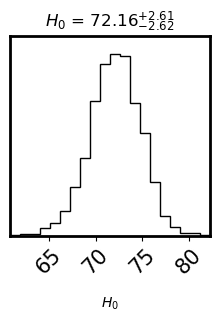

/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_28554/3948224174.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_28554/3948224174.py:64: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


10.623211891759315 reduced chi2
-10.501496499601961 log likelihood
RXJ1131-1231


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [17:46<00:00,  5.33s/it]


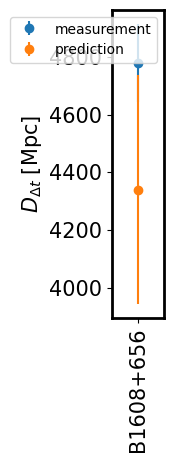

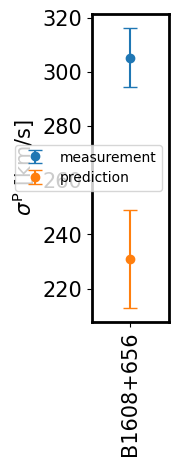

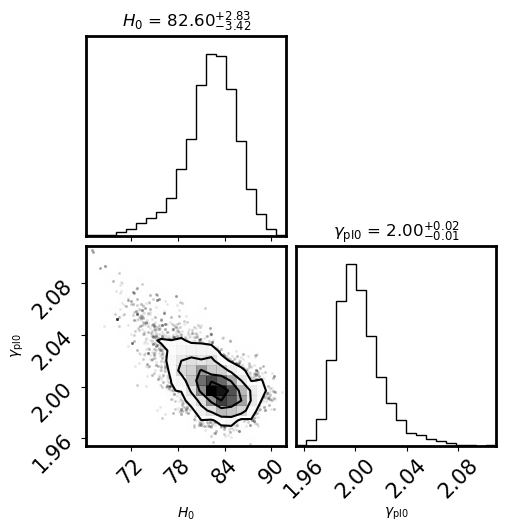

1.5402294385364632 reduced chi2
HE0435-1223


/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_28554/3948224174.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_28554/3948224174.py:60: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_28554/3948224174.py:64: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [13:24<00:00,  4.02s/it]


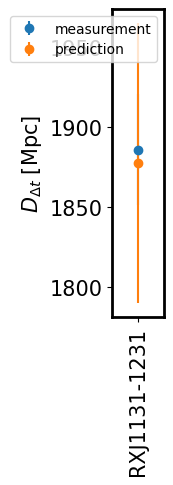

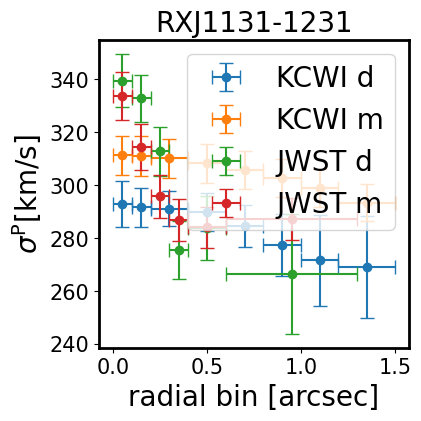

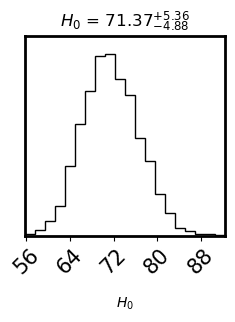

0.32021964155471483 reduced chi2
-0.3210742120972933 log likelihood
SDSS1206+4332


/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_28554/3948224174.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_28554/3948224174.py:64: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [12:13<00:00,  3.67s/it]


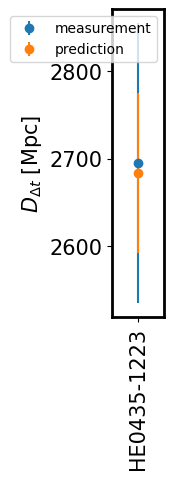

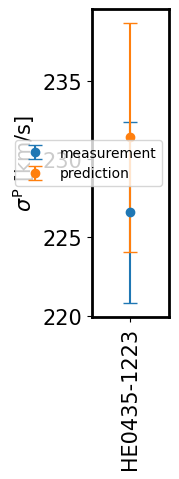

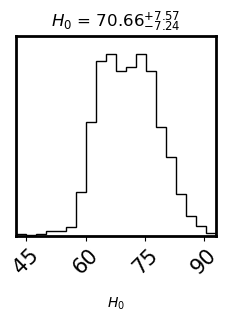

/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_28554/3948224174.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


0.985418996269633 reduced chi2
-0.9989368856735186 log likelihood
WFI2033-4723


/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_28554/3948224174.py:64: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
 62%|███████████████████████████████████████████████████████████████████████████████████▋                                                   | 124/200 [07:51<04:54,  3.87s/it]/Users/sibirrer/Software/hierarc/hierarc/Likelihood/hierarchy_likelihood.py:335: RuntimeWarning: divide by zero encountered in log
  return np.log(likelihood / self._num_distribution_draws)
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [12:43<00:00,  3.82s/it]


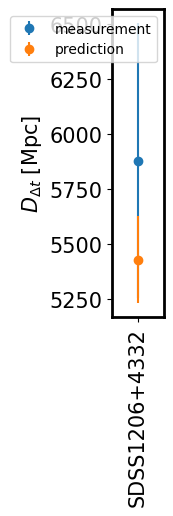

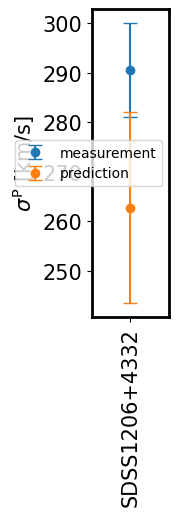

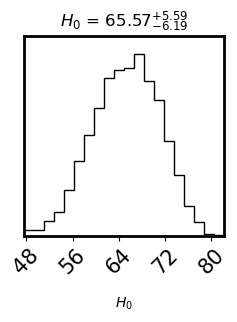

/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_28554/3948224174.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


2.1579605019398294 reduced chi2
-2.2804541784850443 log likelihood
PG1115+080


/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_28554/3948224174.py:64: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [13:56<00:00,  4.18s/it]


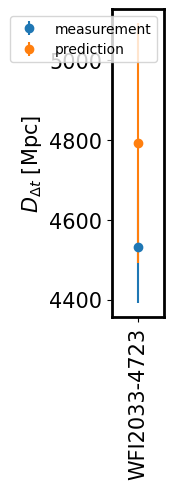

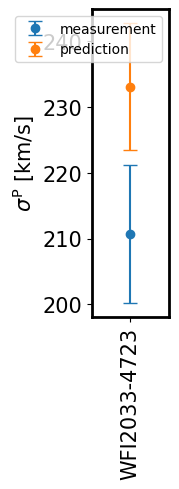

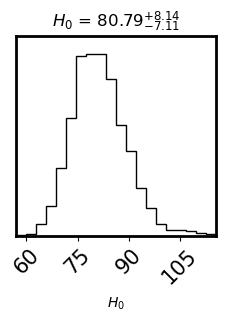

0.8225350803779817 reduced chi2
-0.8385144529058609 log likelihood
DES0408-5354


/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_28554/3948224174.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_28554/3948224174.py:64: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [13:07<00:00,  3.94s/it]


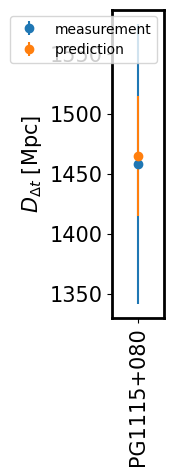

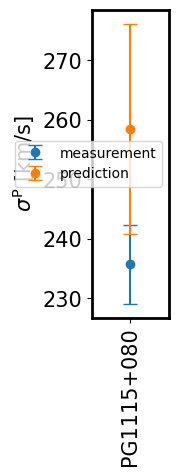

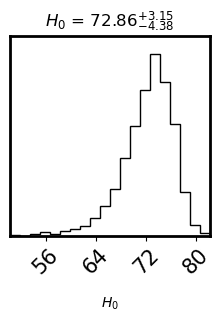

3.24737674386325 reduced chi2
-3.3195247729746375 log likelihood
WGD2038-4008


/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_28554/3948224174.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_28554/3948224174.py:64: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [12:36<00:00,  3.78s/it]


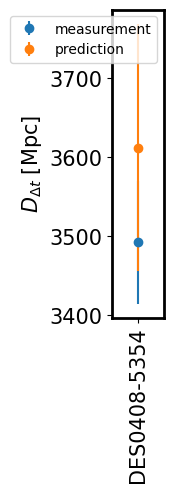

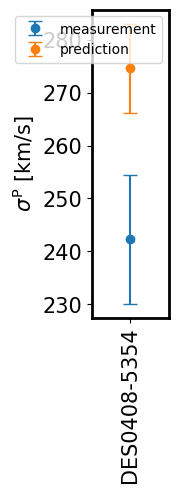

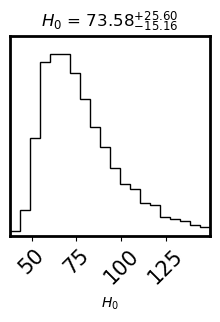

/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_28554/3948224174.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


0.10513897871708308 reduced chi2
-0.10869479835411043 log likelihood


/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_28554/3948224174.py:64: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


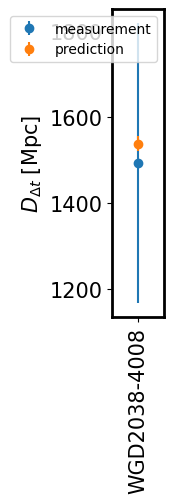

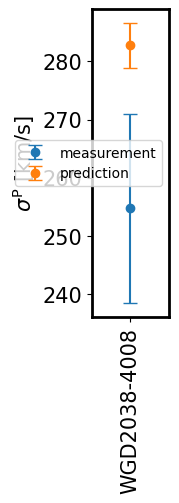

In [16]:
# here we sample the tdcosmo data with free lambda_mst  for each TDCOSMO lens individually
# this is for testing and reproducibility purpose only, as well as whether the data can be described by the model

from hierarc.Diagnostics.blinding import blind_posterior
from hierarc.Diagnostics.goodness_of_fit import GoodnessOfFit



for i in range(len(tdcosmo_posterior_list)):
    # subselect a list of lenses
    if tdcosmo_posterior_list[i]['name'] in lenses_test_list:

        print(tdcosmo_posterior_list[i]['name'])
        kwargs_model = {'lambda_mst_sampling': True, 'lambda_mst_distribution': 'NONE',
                      'anisotropy_sampling': True, 'los_sampling': False, 
                      'los_distributions': None, 'anisotropy_model': anisotropy_model, 
                      'anisotropy_distribution': 'NONE',
                      'anisotropy_parameterization': anisotropy_parameterization,}
        
        mcmc_sampler_tdcosmo_single = MCMCSampler([tdcosmo_posterior_list[i]], cosmology, 
                                                  kwargs_model,
                                                  kwargs_bounds,
                                                  custom_prior=None, interpolate_cosmo=False, 
                                                  num_redshift_interp=100, cosmo_fixed=None)


        mcmc_samples_tdcosmo_single, log_prob_single = mcmc_sampler_tdcosmo_single.mcmc_emcee(n_walkers, n_run, n_burn, kwargs_mean_start, kwargs_sigma_start)
            
        # blind posterior (lines changed only after unblinding)
        #posterior_blinded = blind_posterior(mcmc_samples_tdcosmo_single, mcmc_sampler_tdcosmo_single.param_names(latex_style=False))
        posterior_blinded = mcmc_samples_tdcosmo_single
        corner.corner(posterior_blinded, show_titles=True, labels=mcmc_sampler_tdcosmo_single.param_names(latex_style=True))
        plt.show()

        # get best fit
        index_best_fit = np.where(log_prob_single == np.max(log_prob_single))
        kwargs_cosmo_best_fit, kwargs_lens_best_fit, kwargs_kin_best_fit, _, kwargs_los_best_fit = mcmc_sampler_tdcosmo_single.param.args2kwargs(mcmc_samples_tdcosmo_single[index_best_fit[0][0]])
        cosmo_best_fit = mcmc_sampler_tdcosmo_single.param.cosmo(kwargs_cosmo_best_fit)

        # goodness of fit of kinematics
        gof = GoodnessOfFit([tdcosmo_posterior_list[i]], kwargs_model=kwargs_model)

        f, ax = gof.plot_ddt_fit(cosmo_best_fit, kwargs_lens_best_fit, kwargs_kin_best_fit, kwargs_los_best_fit,
                                 color_measurement=None, color_prediction=None, redshift_trend=False)
        f.show()

        # here we plot the IFU fit in case the data comes in this format
        if tdcosmo_posterior_list[i]['name'] == 'RXJ1131-1231':
            f, ax = plt.subplots(1, 1, figsize=(4, 4))
            ax = gof.plot_ifu_fit(ax, cosmo_best_fit, kwargs_lens_best_fit, kwargs_kin_best_fit, 
                      kwargs_los_best_fit, lens_index=0, bin_edges=radial_bins_kcwi, measurement_indexes=np.arange(len(radial_bins_kcwi) - 1),
                      show_legend=True, data_label='KCWI d', model_label='KCWI m',
                                  color_measurement=None, color_prediction=None)

            ax = gof.plot_ifu_fit(ax, cosmo_best_fit, kwargs_lens_best_fit, kwargs_kin_best_fit, 
                      kwargs_los_best_fit, lens_index=0, bin_edges=radial_bins_jwst, measurement_indexes=np.arange(len(radial_bins_jwst) - 1) + len(radial_bins_kcwi)-1,
                      show_legend=True, data_label='JWST d', model_label='JWST m',
                                  color_measurement=None, color_prediction=None)

            f.show()
        else:
            f, ax = gof.plot_kin_fit(cosmo_best_fit, kwargs_lens_best_fit, kwargs_kin_best_fit, 
                                     kwargs_los_best_fit, color_measurement=None, color_prediction=None)
        f.show()
